In [140]:
# pyright: reportOperatorIssue=false

In [141]:
from IPython.display import display, Math, Markdown
import typing

import sympy as sp
from sympy.printing.latex import LatexPrinter

## Setup

In [142]:
# Main parameters
dx = sp.Symbol('dx', real=True, positive=True)
dt = sp.Symbol('dt', real=True, positive=True)

a = sp.Symbol('a', real=True, positive=True)
cfl = sp.Symbol('cfl', real=True, positive=True)
sigma = sp.Symbol('sigma', latex=r'\sigma', real=True)

# dx and dt latex symbols (passed in sp.Symbol()) seem to be hard-coded to use 
# symbol names, this is a codegen-friendly workaround
symbol_names = {dx: r"\Delta x", dt: r"\Delta t", cfl: r"\nu"}
LatexPrinter.set_global_settings(symbol_names=symbol_names)

Since terms mainly featured throughout (essentially) utilize products of $\Delta x$ and $\nu$ and can reach $\nu^4 \propto 1 / \Delta x^{4}$ in powers, it is necessary to pick right maximum order to leave high enough Big-$\mathcal{O}$ terms across all computations. Most symbols in operations are threated as constants, therefore they might get wholly absorbed by $\mathcal{O}(\Delta x^{\alpha})$ terms -- that is without utilizing relanshionships between variables (such as $\Delta t \propto \Delta x$) in expansions and subsequently reducing total order when divided by any powers of $\Delta x$.

*Note: this could be probably be more elegantly (but less generally) solved if one wishes to write `sympy` constraints.*

In [143]:
# Derivatives
x = sp.Symbol('x', real=True)
u = sp.Function('u')
order = 9  # Expansion order = O(dx^9) -- the highest term kept is dx^9
derivs = tuple(sp.Derivative(u(x), (x, i)) for i in range(0, order))

In [144]:
# Stencil
u_im2 = sp.Symbol('u_im2')
u_im1 = sp.Symbol('u_im1')
u_i = sp.Symbol('u_i')
u_ip1 = sp.Symbol('u_ip1')
u_ip2 = sp.Symbol('u_ip2')
stencil = (u_im2, u_im1, u_i, u_ip1, u_ip2)

# This is just appears to be a better practice with sympy for consistency
symbol_names |= {
    stecil_point: "u^n_" + subscript for stecil_point, subscript in
    zip(stencil, ['{i - 2}', '{i - 1}', 'i', '{i + 1}', '{i + 2}'], strict=True)
}
LatexPrinter.set_global_settings(symbol_names=symbol_names)

stencil_taylors: typing.Mapping[sp.Basic | complex, sp.Expr] = {
    stecil_point: u(x + offset * dx).series(dx, 0, order).doit()
    for offset, stecil_point in enumerate(stencil, -2)
}

In [145]:
''' This cell is for small pretty printing utilities.

See

https://docs.sympy.org/latest/modules/printing.html#example-of-custom-printer

for examples.
'''

class BaseOrderedPrinter(LatexPrinter):
    '''
    Reusable Term Ordering Logic. Intercepts sympy.Add to sort terms based on 
    subclass priority rules.
    '''

    def _get_term_priority(self, term) -> tuple[int, int]:
        return (0, 0)

    def _print_Add(self, expr: sp.Expr, order=None):
        def priority_key(term):
            # Force Big-O terms to end
            if term.is_Order:
                return (99, 0)
            return self._get_term_priority(term)

        # Sort terms safely
        sorted_terms = sorted(expr.args, key=priority_key)
        ordered_expr = sp.Add(*sorted_terms, evaluate=False)

        # Print with sorting disabled so our order is respected
        old_order = self._settings.get('order')
        self._settings['order'] = 'none'
        result = super()._print_Add(ordered_expr, order='none')
        self._settings['order'] = old_order

        return result


class PrettyDerivativePrinter(LatexPrinter):
    ''' Only concerns itself with formatting u(x) and its derivatives. '''

    def _print_Function(self, expr: sp.Function, exp: sp.Expr | None = None):
        if getattr(expr.func, '__name__', '') == 'u':
            return f"u^{{{exp}}}" if exp is not None else "u"
        return super()._print_Function(expr, exp)

    def _print_Derivative(self, expr: sp.Derivative):
        func = expr.args[0]
        if getattr(getattr(func, 'func', None), '__name__', '') == 'u':
            n = len(expr.variables)
            var = expr.variables[0].name if expr.variables else 'x'
            sub = var * n

            if n == 0:
                return "u"
            elif n <= 3:
                return f"u_{{{sub}}}"
            else:
                roman = {4: 'IV', 5: 'V', 6: 'VI', 7: 'VII', 8: 'VIII'}
                return f"u^{{({roman.get(n, str(n))})}}_{{{sub}}}"

        return super()._print_Derivative(expr)


class StencilPrinter(BaseOrderedPrinter):
    ''' Sorts spatial stencil symbols. '''

    def __init__(self, settings=None):
        super().__init__(settings)
        self.stencil_syms = [
            sp.Symbol('u_im2'), sp.Symbol('u_im1'), sp.Symbol('u_i'),
            sp.Symbol('u_ip1'), sp.Symbol('u_ip2')
        ]

    def _get_term_priority(self, term):
        for i, sym in enumerate(self.stencil_syms):
            if term.has(sym):
                return (0, i)
        # Extra terms go at the end
        return (1, 0)


class SeriesPrinter(BaseOrderedPrinter, PrettyDerivativePrinter):
    ''' Sorts Taylor series by derivative degree and formats nicely. '''

    def _get_term_priority(self, term: sp.Expr):
        # Look for Derivative objects
        derivs = term.atoms(sp.Derivative)
        u_derivs = [deriv for deriv in derivs if getattr(
            getattr(deriv.args[0], 'func', None), '__name__', '') == 'u']
        if u_derivs:
            return (0, len(u_derivs[0].variables))

        # Look for base function u(x)
        funcs = term.atoms(sp.Function)
        u_funcs = [f for f in funcs if getattr(f.func, '__name__', '') == 'u']
        if u_funcs:
            return (0, 0)

        # Extra terms (constants, plain variables) go at the end
        return (1, 0)


def latex_stencil(expr: sp.Expr, **settings) -> str:
    return StencilPrinter(settings).doprint(expr)


def latex_series(expr: sp.Expr, **settings) -> str:
    return SeriesPrinter(settings).doprint(expr)

In [146]:
''' Sanity check '''
display(Markdown("Taylor expansions:"))
for stencil_point, expansion in stencil_taylors.items():
    if stencil_point != u_i: # Skip center point
        display(Math(fr"{sp.latex(stencil_point)} = {latex_series(expansion)} + \ldots"))

Taylor expansions:

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Method

In [147]:
u_next = \
    sigma * u_i + (1 - sigma) * (u_ip1 + u_im1) / 2 \
    + -a * dt * (u_ip1 - u_im1) / (2 * dx) \
    + (a * dt)**2 / 2 * (u_ip1 - 2 * u_i + u_im1) / dx**2

u_taylor: sp.Expr = u(x - a * dt).series(dt, 0, order)

In [148]:
def to_stencil_form(expr: sp.Expr) -> sp.Expr:
    """ Helper function """
    return sp.collect(sp.expand(expr), stencil)

In [149]:
# display(Markdown(""))
display(Math(
    f"u_i^{{n+1}} = {latex_stencil(sp.simplify(to_stencil_form(u_next)))}"
))
display(Math(
    f"u_i^{{n+1}} = {latex_series(sp.simplify(sp.collect(sp.expand(u_next.subs(stencil_taylors)), derivs)))}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [150]:
def get_coeff(expr: sp.Expr, deriv: sp.Derivative) -> sp.Basic:
    return sp.together(sp.simplify(sp.expand(expr.doit()).coeff(deriv)))


u_next_taylor = sp.expand(u_next.subs(stencil_taylors))
error = sp.expand(u_next_taylor - u_taylor)

error_coeffs = tuple(get_coeff(error, deriv) for deriv in derivs)

In [151]:
table = r"""
\begin{array} {r r r} \\
& \text{Coefficient} & \text{Error coefficient} \\
\hline \\
"""

# # Decorative purpose only
# pretty_derivs_symbol_names = {
#     deriv: fr"\dfrac{{\partial^{k} u}}{{\partial x^{k}}}"
#     for k, deriv in enumerate(derivs)
# } | {u: "u", u_x: r"\dfrac{\partial u}{\partial x}"}

# for deriv, error_coeff in zip(derivs, error_coeffs):
#     table += fr"{sp.latex(deriv, symbol_names=pretty_derivs_symbol_names)} : &\quad \
#                     {sp.latex(get_coeff(u_next_taylor, deriv), fold_short_frac=True)} &\quad \
#                     {sp.latex(error_coeff, fold_short_frac=True)} \\[1em]"

table += r"\end{array}"
display(Math(table))

<IPython.core.display.Math object>

The goal here is to strip away the common factors (like $\Delta t$, $\Delta x$, and factorial denominators from the Taylor series) to isolate the "raw" constants of the error.
*   **`* sp.factorial(k)`**: Cancels out the $1/k!$ term from the Taylor expansion.
*   **`* 6 / (a**3 * dt**3 * dx**k)`**: The leading order of the error for this specific scheme is expected to be $O(a^3 \Delta t^3)$. Dividing by this normalizes the error terms, essentially asking: *"What is the coefficient of the $k$-th derivative relative to the leading error term?"*

In [152]:
error_vector = sp.Matrix(error_coeffs[:5])
# IMPORTANT adjustment that determines the order (4th) and value of error
error_vector[4] -= ((sigma - 1) * dx**4) / 24

display(Math(fr"{sp.latex(sp.simplify(error_vector.T))}^T"))

<IPython.core.display.Math object>

This creates a $5 \times 5$ matrix representing the "structure" of the 5-point stencil ($u_{i-2}$ to $u_{i+2}$). 
*   Each row corresponds to a derivative order $k$ ($0, 1, 2, 3, 4$).
*   Each column corresponds to a stencil offset ($-2, -1, 0, 1, 2$).
*   Because we already accounted for $1/k!$ and $\Delta x^k$ in the normalization step, the Taylor coefficient for offset $j$ and order $k$ is simply $j^k$. (The `0**k if k > 0 else 1` handles the $0^0 = 1$ edge case for the $u_i$ term).

In [153]:
taylor_matrix = sp.Matrix([
    [(j * dx)**k / sp.factorial(k) for j in (-2, -1, 0, 1, 2)]
    for k in range(5)
])

# more readable format
normalization = sp.diag(*[sp.factorial(k) / dx**k for k in range(5)])

display(Math(
    fr"{sp.latex(sp.simplify(normalization * taylor_matrix))} x = \
       {sp.latex(sp.simplify(normalization * error_vector))}"
))

correction_coeffs: sp.Matrix = taylor_matrix.solve(error_vector)

# pretty printing factoring out of denominator
gcd = 24 * dx**4
display(Math(
    fr"x = {sp.latex(1 / gcd)} \cdot {sp.latex(sp.simplify(correction_coeffs * gcd))}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [154]:
correction_term: sp.Expr = -correction_coeffs.dot(stencil)
u_corrected = u_next + correction_term
u_corrected_taylor = sp.expand(u_corrected.subs(stencil_taylors))
error_corrected = sp.expand(u_corrected_taylor - u_taylor)

In [155]:
display(Math(
    latex_stencil(sp.simplify(to_stencil_form(u_corrected)), long_frac_ratio=1)
))

<IPython.core.display.Math object>

In [156]:
for deriv in derivs:
    coeff = sp.simplify(get_coeff(error_corrected, deriv))
    if coeff != 0:
        display(Markdown("Coefficient of highest-order error term ${}$:"
                         .format(PrettyDerivativePrinter().doprint(deriv))))
        display(Math(f"{sp.latex(coeff)}"))
        break

Coefficient of highest-order error term $u^{(IV)}_{xxxx}$:

<IPython.core.display.Math object>

In [157]:
u_corrected_cfl: sp.Expr = sp.simplify(u_corrected.subs(a*dt, cfl*dx))

# Sanity checks
assert u_corrected_cfl.coeff(a) == 0 and u_corrected_cfl.coeff(dt) == 0, \
    "Unexpected form after rewrite"

stencil_points_coeffs: tuple[sp.Expr, ...] = tuple(
    sp.simplify(sp.expand(u_corrected_cfl).coeff(stencil_point))
    for stencil_point in stencil)  # type: ignore

assert sp.Add(*stencil_points_coeffs) == 1, "Coefficients don't sum to 1"

In [158]:
display(Markdown("Complete numerical scheme (CFL form):"))

display(Math(
    fr"u_i^{{n+1}} = {latex_stencil(sp.simplify(to_stencil_form(u_corrected_cfl)))}"
))

# TODO -- extract back to a separate function 
u_correted_cfl_taylor: sp.Order = sp.expand(u_corrected_cfl.subs(stencil_taylors).doit())
O_term = u_correted_cfl_taylor.getO()
assert O_term, "Expression does not contain a Big-O term!"

error_order = sp.degree(O_term.expr, dx) # type: ignore
assert error_order >= 5, f"Expected order >= 5, but got O({dx}**{error_order})"

display(Math(
    latex_series(sp.collect(sp.simplify(u_correted_cfl_taylor.removeO()), derivs) + O_term)
))

Complete numerical scheme (CFL form):

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [159]:
def save_to_python_module(expr, filename: str = "mlf_method.py"):
    """Save the complete method as a Python module."""
    
    module_content = f'''
"""
Programmatically-generated Lax-Friedrichs-type 4th-order scheme for solving the
advection equation.
"""

import numpy as np
import numpy.typing as npt

def mlf_step(
    u: npt.NDArray[np.floating],
    dx: np.floating, cfl: np.floating, sigma: np.floating, **_,
) -> npt.NDArray[np.floating]:
    """
    Apply the method using array indexing.
    
    Parameters
    ----------
    u
        Current solution array
    dx
        Spatial step size
    cfl
        CFL number (nu = a*dt/dx)
    sigma
        Dissipation parameter
    
    Returns
    -------
    u_next
        Updated value(s)
    """
    u_next = np.zeros_like(u)
    i = np.arange(2, len(u) - 2)

    u_im2 = u[i-2]
    u_im1 = u[i-1]
    u_i = u[i]
    u_ip1 = u[i+1]
    u_ip2 = u[i+2]

    # TODO -- add mypy warning supression
    # pylint: disable=line-too-long
    u_next[i] = {sp.printing.pycode(expr)}
    return u_next
'''
    
    with open(filename, 'w') as file:
        file.write(module_content)
        print(f"Saved method to {filename}")
    

save_to_python_module(u_corrected_cfl, "mlf_method.py")

Saved method to mlf_method.py


## Stability analysis

In [160]:
def amplification_factor(
        coeffs: tuple[sp.Expr, ...],
        wavenumber: sp.Symbol = sp.Symbol('theta', real=True),
        js: typing.Iterable[int] | None = None) -> sp.Expr:
    """Return G(theta) = sum c_j * exp(I * j * theta)."""
    js = js or range(-(len(coeffs) // 2), len(coeffs) // 2 + 1)
    factor = sp.Add(*[coeff * sp.exp(sp.I * j * wavenumber)
                      for coeff, j in zip(coeffs, js, strict=True)])
    return factor

In [161]:
def squared_modulus(factor: sp.Expr) -> sp.Expr:
    """Return |G|^2 as a real trigonometric expression in theta."""
    # We do not replace(sp.conjugate(wavenumber), wavenumber)
    # sympy handles assumption that theta is real
    factor_conjugate = sp.conjugate(factor)
    return sp.expand_complex(factor * factor_conjugate)

In [162]:
wavenumber = sp.Symbol('theta', real=True)

factor = amplification_factor(stencil_points_coeffs, wavenumber)
factor_mod_squared = squared_modulus(factor)

### Stability bounds

$|G|^2$ contains only even powers of $\nu$ (CFL), so we set $\mu = \nu^2$ to keep the algebra low‑degree.  

Stability requires $\max_{x\in[-1,1]} P(x,\mu) \le 1$. For a consistent centred scheme one usually has $P(1)=P(-1)=1$; the first violation occurs when an interior maximum touches $1$. That gives the system  
$P(x,\mu)-1 = 0,\quad \partial P/\partial x = 0,$ which we eliminate $x$ from via a resultant. The result is a polynomial in $\mu$ whose smallest positive root is $\mu_{\max}$. The CFL limit is $\nu_{\max} = \sqrt{\mu_{\max}}$.

*Expected result:*  
`stability_eq` is an algebraic equation $F(\mu, \sigma) = 0$. In many cases it factors into a product of polynomials. The factor that gives the smallest positive $\mu$ is the one we care about. For example, you may get an equation like  
$$
a(\sigma)\,\mu^3 + b(\sigma)\,\mu^2 + c(\sigma)\,\mu + d(\sigma) = 0,
$$  
or even a quadratic/linear factor. The stability condition is then  
$$
|\nu| \le \sqrt{\mu_{\max}(\sigma)}.
$$

If the degree in $\mu$ is ≤4, you can solve analytically; otherwise, `nroots` gives the numerical limit for any given $\sigma$.

*Note on boundaries:*  
If `sp.simplify(P.subs(x, 1))` or `P.subs(x, -1)` is not identically 1, you must also check that `P( ±1, mu) ≤ 1`. Those give separate polynomial inequalities in $\mu$ that may cut the allowed interval before the interior hump does. The overall $\mu_{\max}$ is the smallest positive number at which any of these constraints becomes violated. In practice, for a 5‑point centred 4th‑order scheme, the interior critical point typically dictates the bound.

Interior critical points: P = 1 and dP/dx = 0

In [163]:
def derive_stability_conditions(
    factor_mod_squared: sp.Expr,
    wavenumber: sp.Symbol,
    cfl: sp.Symbol,
    # FIXME -- probably tuple. Doesn't seem to be a need fro pre-factoring
) -> typing.Iterable[sp.Poly]:
    """
    Derives the interior and boundary stability conditions from the amplification factor.
    Returns equations (where each expression implicitly equals 0).
    """
    x = sp.Symbol('x', real=True)

    # NOTE: expand(trig=True) is implemented using Chebyshev polynomials.
    # There might be some simplier function *somewhere* in sympy.
    # NOTE: Proper way may need to use other simplification, like:
    #   sp.expand_trig(sp.simplify(factor_mod_squared))
    # But this seems to be mush faster and good enough
    expr: sp.Expr = sp.cancel(sp.expand_trig(factor_mod_squared))
    factor_poly = sp.Poly(sp.simplify(
        expr.subs(sp.sin(wavenumber)**2, 1 - sp.cos(wavenumber)**2)
            .subs(sp.cos(wavenumber), x)), [x, cfl]
    )

    # This is our important assumption. A little crude execution.
    mu = sp.Symbol('mu', nonnegative=True, real=True)
    assert not factor_poly.subs(cfl, sp.sqrt(mu)).has_free(cfl), \
        "Expected Polynomial to include only even powers"

    factor_poly_prime: sp.Poly = sp.diff(factor_poly, x)  # type: ignore

    resultant = sp.Poly(sp.resultant(factor_poly - 1, factor_poly_prime, x), [cfl])
    assert not resultant.subs(cfl, sp.sqrt(mu)).has_free(cfl), \
        "Expected Resultant to include only even powers"

    # Condition at the endpoints
    end_left, end_right = (sp.Poly(factor_poly.subs(x, x_value) - 1, [cfl])
                           for x_value in [1, -1])

    return (end_left, resultant, end_right)

In [164]:
left, interior, right = derive_stability_conditions(factor_mod_squared, wavenumber, cfl)

print("Stability equations (smallest positive mu from these gives mu_max):")
print("Interior critical points:")
display(interior)
print("\nEndpoint x = +1:")
display(left)
print("\nEndpoint x = -1:")
# LC(p, x) * prod((x - r) for r in roots(p, x, multiple=True))
display(sp.factor(right, extension=True))
# DEBUG
display(sp.roots(right))
display(sp.LC(right, cfl) * sp.prod((cfl - r) for r in sp.roots(right, cfl, multiple=True)))

Stability equations (smallest positive mu from these gives mu_max):
Interior critical points:


Poly(0, cfl, domain='ZZ')


Endpoint x = +1:


Poly(0, cfl, domain='QQ[sigma]')


Endpoint x = -1:


Poly(4/9*cfl**8 - 32/9*cfl**6 + (8*sigma/9 + 68/9)*cfl**4 + (-32*sigma/9 - 16/9)*cfl**2 + 4*sigma**2/9 + 4*sigma/9 - 8/9, cfl, domain='QQ[sigma]')

{-sqrt(sqrt(5 - sigma) + 2): 1,
 -sqrt(2 - sqrt(5 - sigma)): 1,
 sqrt(sqrt(5 - sigma) + 2): 1,
 sqrt(2 - sqrt(5 - sigma)): 1,
 -sqrt(sqrt(2 - sigma) + 2): 1,
 -sqrt(2 - sqrt(2 - sigma)): 1,
 sqrt(sqrt(2 - sigma) + 2): 1,
 sqrt(2 - sqrt(2 - sigma)): 1}

4*(cfl - sqrt(2 - sqrt(2 - sigma)))*(cfl + sqrt(2 - sqrt(2 - sigma)))*(cfl - sqrt(2 - sqrt(5 - sigma)))*(cfl + sqrt(2 - sqrt(5 - sigma)))*(cfl - sqrt(sqrt(2 - sigma) + 2))*(cfl + sqrt(sqrt(2 - sigma) + 2))*(cfl - sqrt(sqrt(5 - sigma) + 2))*(cfl + sqrt(sqrt(5 - sigma) + 2))/9

In [165]:
def evaluate_nu_max(cfl_expressions: list[sp.Expr], sigma_sym: sp.Symbol, sigma_val: float) -> float:
    """
    Substitutes a numerical sigma value into the purely symbolic cfl expressions
    to find the critical real limit for plotting.
    """
    positive_real_roots = []
    
    for expr in cfl_expressions:
        # Substitute sigma into the exact symbolic root
        val = expr.subs(sigma_sym, sigma_val)
        
        # Evaluate to a complex number to check imaginary parts
        val_num = complex(sp.N(val))
        
        # Filter for real, positive roots
        if abs(val_num.imag) < 1e-12 and val_num.real > 1e-12:
            positive_real_roots.append(val_num.real)
            
    if not positive_real_roots:
        return float('inf')
        
    return min(positive_real_roots)

In [166]:
def solve_cfl_symbolically(conditions: typing.Iterable[sp.Poly], cfl: sp.Symbol) -> list[sp.Expr]:
    """
    Extracts final expressions for the value of cfl.
    Performs strictly symbolic finding of roots (cfl as a function of sigma, etc).
    """
    cfl_expressions = []
    
    for eq in conditions:
        if eq == 0:
            continue
            
        # Symbolically solve for CFL. 
        # (Since the equations only have even powers, this is effectively solving for mu)
        roots = sp.solve(eq, cfl)
        
        # Collect all branches
        cfl_expressions.extend(roots)
        
    return cfl_expressions
conditions = derive_stability_conditions(factor_mod_squared, wavenumber, cfl)
cfl_exprs = solve_cfl_symbolically(conditions, cfl)

evaluate_nu_max(cfl_exprs, sigma, 0.5)

0.8804857344718374

### Numerical results

In [167]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import matplotlib.axes

In [168]:
factor_numeric: typing.Callable[
    [npt.ArrayLike, npt.ArrayLike, np.floating],
    npt.NDArray[np.floating]
] = sp.lambdify((wavenumber, cfl, sigma), factor, modules='numpy')

In [169]:

def find_stability_bound_numerically(coeffs: list, sigma_val: float, 
                                    cfl_range: tuple[float, float] = (0.01, 2.0)) -> float:
    """Numerically find maximum stable CFL for given sigma."""
    theta_test = np.linspace(0, 2*np.pi, 1000)
    
    for cfl_test in np.linspace(cfl_range[1], cfl_range[0], 500):
        factor_values = factor_numeric(theta_test, cfl_test, sigma_val)
        if np.all(np.abs(factor_values)**2 <= 1.0 + 1e-12):
            return cfl_test
    
    return None  # No stable CFL found

In [170]:
def plot_stability_region(sigma_values: typing.Sequence[float]=(0.0, 0.5, 1.0),
                          theta_range: tuple[float, float] = (0.0, 2*np.pi),
                          cfl_range: tuple[float, float] = (0.01, 1.5),
                          n_theta=200, n_cfl=100):
    """Numerically compute and plot |G|^2 over pairs $(\\theta, \\nu)$ for several $\\sigma$."""
    theta_values = np.linspace(*theta_range, n_theta)
    cfl_values = np.linspace(*cfl_range,   n_cfl)
    THETA, CFL = np.meshgrid(theta_values, cfl_values)

    fig, axes = plt.subplots(1, len(sigma_values),
                             figsize=(5 * len(sigma_values), 4),
                             squeeze=False)

    for ax, sigma_value in zip(axes[0], sigma_values):
        ax: matplotlib.axes.Axes
        factor_values = factor_numeric(THETA, CFL, sigma_value)
        factor_mod_sq = np.abs(factor_values)**2

        contour = ax.contourf(THETA, CFL, factor_mod_sq, levels=50, cmap='RdYlGn_r')
        ax.contour(THETA, CFL, factor_mod_sq, levels=[1.0],
                   colors='black', linewidths=2)

        # TODO -- Here and everywhere we should probably use rational multiples
        # of pi as ticks
        ax.set_xlabel(r'Wavenumber $\theta = k\,\Delta x$')
        ax.set_ylabel(r'CFL-number $\nu$')
        ax.set_title(rf'$\sigma = {sigma_value}$,  $|G|^2$')
        fig.colorbar(contour, ax=ax, label=r'$|G|^2$')

    fig.tight_layout()
    plt.show()

    # Maximum stable CFL per sigma
    print("\nMaximum stable CFL (|G|² ≤ 1 for all θ):")
    fine_theta = np.linspace(*theta_range, 1000)
    for sig in sigma_values:
        cfl_max = None
        for cfl_test in np.linspace(cfl_range[1], cfl_range[0], 600):
            factor_values = factor_numeric(fine_theta, cfl_test, sig)
            if np.all(np.abs(factor_values)**2 <= 1.0 + 1e-10):
                cfl_max = cfl_test
                break
        if cfl_max is not None:
            print(f"  σ = {sig}: ν_max ≈ {cfl_max:.4f}")
        else:
            print(f"  σ = {sig}: no stable ν found in {cfl_range}")

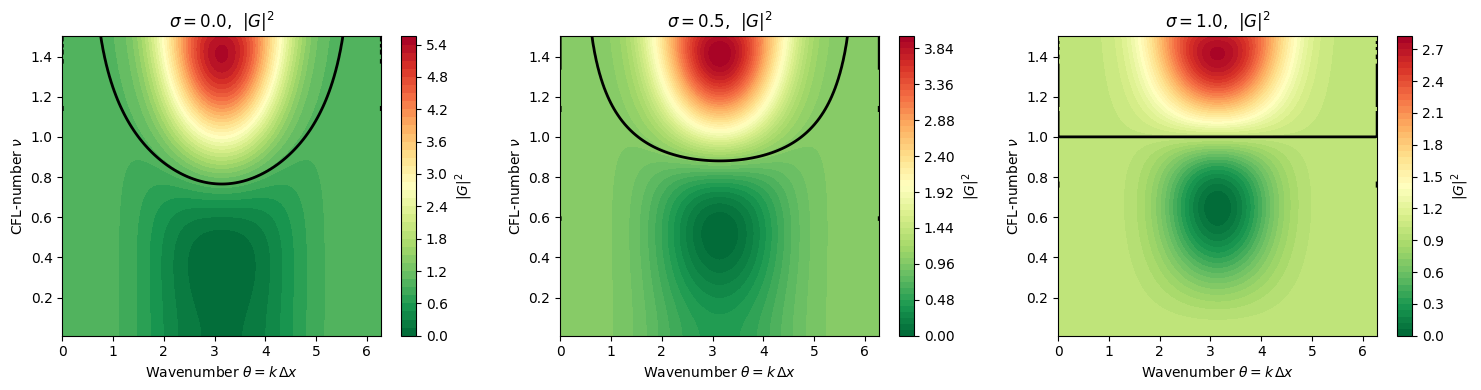


Maximum stable CFL (|G|² ≤ 1 for all θ):
  σ = 0.0: ν_max ≈ 0.7637
  σ = 0.5: ν_max ≈ 0.8781
  σ = 1.0: ν_max ≈ 0.9975


In [171]:
plot_stability_region(sigma_values=(0.0, 0.5, 1.0))

In [172]:
def plot_3d_stability_surface(sigma_range: tuple[float, float] = (0.0, 2.0),
                             theta_range: tuple[float, float] = (0.0, 2*np.pi),
                             cfl_range: tuple[float, float] = (0.01, 1.5),
                             n_sigma=20, n_theta=100, n_cfl=80):
    """3D surface plot showing |G|^2 = 1 stability boundary."""
    
    # Create grid
    sigma_vals = np.linspace(*sigma_range, n_sigma)
    theta_vals = np.linspace(*theta_range, n_theta)
    cfl_vals = np.linspace(*cfl_range, n_cfl)
    
    # Find stability boundary for each (sigma, theta) pair
    SIGMA, THETA = np.meshgrid(sigma_vals, theta_vals)
    CFL_BOUNDARY = np.zeros_like(SIGMA)
    
    for i, sig in enumerate(sigma_vals):
        for j, th in enumerate(theta_vals):
            # Binary search for CFL where |G|^2 = 1
            cfl_low, cfl_high = cfl_range
            for _ in range(50):  # Binary search iterations
                cfl_mid = (cfl_low + cfl_high) / 2
                factor_val = factor_numeric(th, cfl_mid, sig)
                if np.abs(factor_val)**2 > 1.0:
                    cfl_high = cfl_mid
                else:
                    cfl_low = cfl_mid
            CFL_BOUNDARY[j, i] = cfl_mid
    
    # 3D surface plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(SIGMA, THETA, CFL_BOUNDARY, 
                          cmap='viridis', alpha=0.8)
    
    ax.set_xlabel(r'Parameter $\sigma$')
    ax.set_ylabel(r'Wavenumber $\theta$')
    ax.set_zlabel(r'Critical CFL $\nu_{max}$')
    ax.set_title('Stability Boundary Surface')
    
    plt.colorbar(surf, shrink=0.5)
    plt.show()

def plot_max_cfl_vs_sigma(sigma_range: tuple[float, float] = (0.0, 2.0),
                         theta_range: tuple[float, float] = (0.0, 2*np.pi),
                         cfl_range: tuple[float, float] = (0.01, 1.5),
                         n_sigma=100):
    """Plot maximum stable CFL as function of sigma."""
    
    sigma_vals = np.linspace(*sigma_range, n_sigma)
    max_cfl_vals = []
    
    fine_theta = np.linspace(*theta_range, 500)
    
    for sig in sigma_vals:
        cfl_max = None
        for cfl_test in np.linspace(cfl_range[1], cfl_range[0], 300):
            factor_values = factor_numeric(fine_theta, cfl_test, sig)
            if np.all(np.abs(factor_values)**2 <= 1.0 + 1e-12):
                cfl_max = cfl_test
                break
        max_cfl_vals.append(cfl_max if cfl_max is not None else 0)
    
    plt.figure(figsize=(10, 6))
    plt.plot(sigma_vals, max_cfl_vals, 'b-', linewidth=2)
    plt.xlabel(r'Parameter $\sigma$')
    plt.ylabel(r'Maximum stable CFL $\nu_{max}$')
    plt.title('Maximum Stable CFL vs Parameter σ')
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_stability_contours_multi_sigma(sigma_values: list[float] = [0.0, 0.2, 0.5, 0.8, 1.0],
                                       theta_range: tuple[float, float] = (0.0, 2*np.pi),
                                       cfl_range: tuple[float, float] = (0.01, 1.5)):
    """Plot stability boundary contours for multiple sigma values on same plot."""
    
    theta_vals = np.linspace(*theta_range, 300)
    
    plt.figure(figsize=(10, 8))
    
    colors = plt.colormaps['viridis'](np.linspace(0, 1, len(sigma_values)))
    
    for sig, color in zip(sigma_values, colors):
        cfl_boundary = []
        for th in theta_vals:
            # Binary search for boundary CFL
            cfl_low, cfl_high = cfl_range
            for _ in range(40):
                cfl_mid = (cfl_low + cfl_high) / 2
                factor_val = factor_numeric(th, cfl_mid, sig)
                if np.abs(factor_val)**2 > 1.0:
                    cfl_high = cfl_mid
                else:
                    cfl_low = cfl_mid
            cfl_boundary.append(cfl_mid)
        
        plt.plot(theta_vals, cfl_boundary, color=color, 
                linewidth=2, label=f'σ = {sig}')
    
    plt.xlabel(r'Wavenumber $\theta$')
    plt.ylabel(r'Critical CFL $\nu_{max}$')
    plt.title('Stability Boundaries for Various σ')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

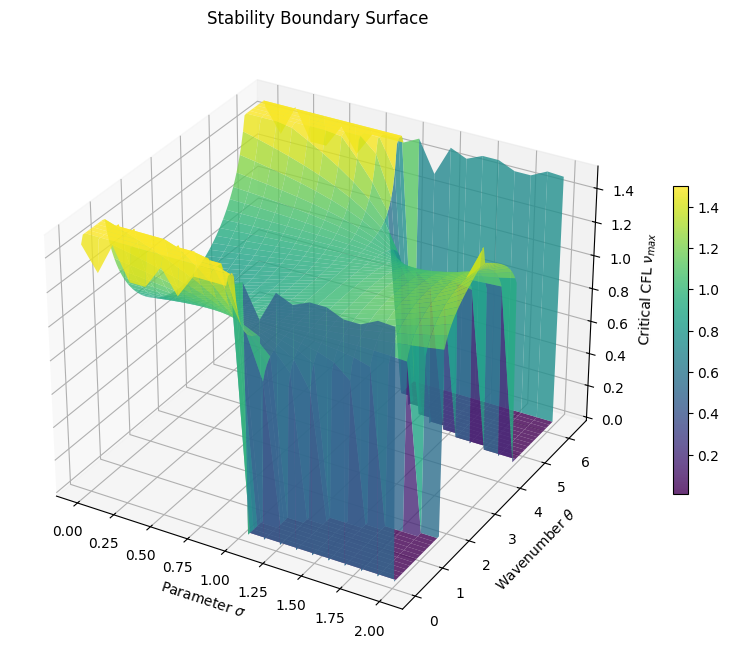

In [173]:
plot_3d_stability_surface()

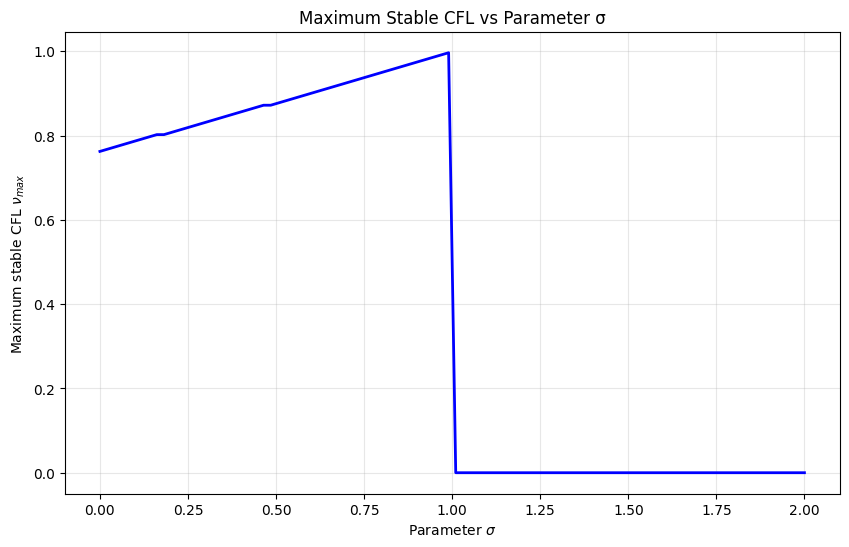

In [174]:
plot_max_cfl_vs_sigma()

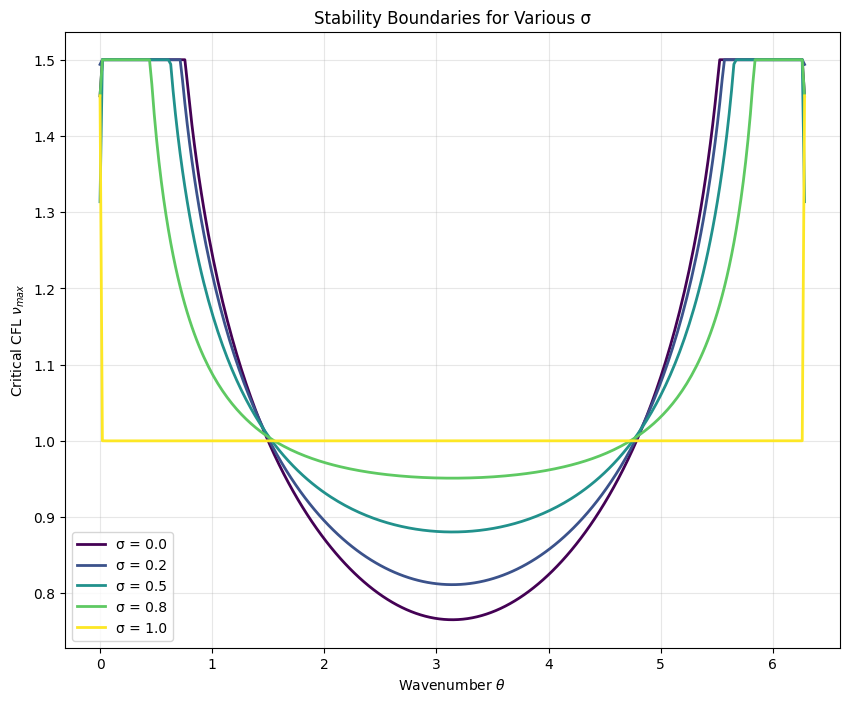

In [175]:
plot_stability_contours_multi_sigma()

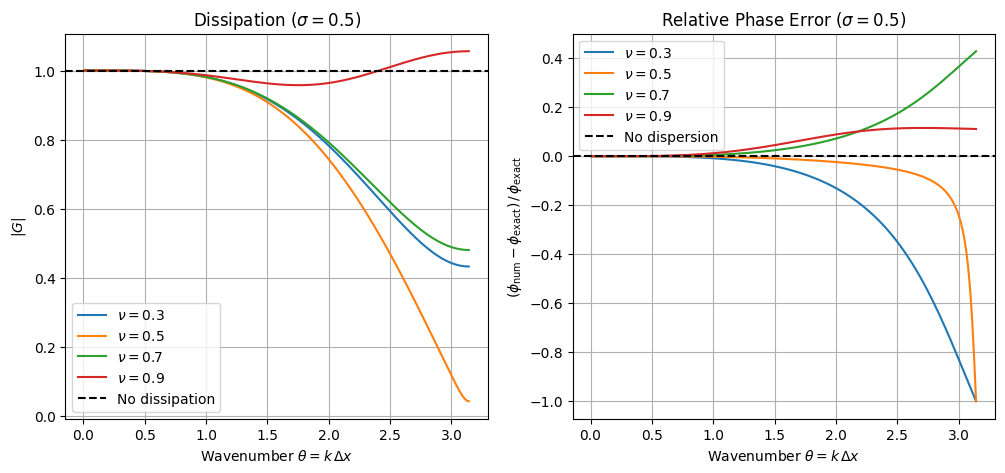

In [176]:
def dissipation_dispersion(
    sigma_value: np.floating,
    cfl_values: npt.NDArray[np.floating],
    n_theta: int,
):
    theta_values = np.linspace(0.01, np.pi, n_theta)
    # For stacked operation
    cfl_values = np.expand_dims(cfl_values, axis=-1)
    factor_values = factor_numeric(theta_values, cfl_values, sigma_value)
    phi_numeric = -np.angle(factor_values)
    phi_exact = cfl_values * theta_values
    phase_errors = (phi_numeric - phi_exact) / (phi_exact + 1e-12)
    return theta_values, np.abs(factor_values), phase_errors


def plot_dissipation(
    sigma_value: np.floating, *,
    cfl_values: npt.NDArray[np.floating],
    theta_values: npt.NDArray[np.floating],
    factor_values: npt.NDArray[np.floating],
    ax: matplotlib.axes.Axes,
):
    for cfl_value, data in zip(cfl_values, factor_values):
        ax.plot(theta_values, data, label=fr'$\nu = {cfl_value}$')

    ax.axhline(1.0, color='k', linestyle='--', label='No dissipation')
    ax.set_xlabel(r'Wavenumber $\theta = k\,\Delta x$')
    ax.set_ylabel(r'$|G|$')
    ax.set_title(rf'Dissipation ($\sigma = {sigma_value}$)')
    ax.legend()
    ax.grid(True)

    return ax


def plot_dispersion(
    sigma_value: np.floating, *,
    cfl_values: npt.NDArray[np.floating],
    theta_values: npt.NDArray[np.floating],
    phase_errors: npt.NDArray[np.floating],
    ax: matplotlib.axes.Axes,
):
    for cfl_value, data in zip(cfl_values, phase_errors):
        ax.plot(theta_values, data, label=fr'$\nu = {cfl_value}$')

    ax.axhline(0.0, color='k', linestyle='--', label='No dispersion')
    ax.set_xlabel(r'Wavenumber $\theta = k\,\Delta x$')
    ax.set_ylabel(
        r'$(\phi_{\mathrm{num}} - \phi_{\mathrm{exact}})\,/\,\phi_{\mathrm{exact}}$'
    )
    ax.set_title(rf'Relative Phase Error ($\sigma = {sigma_value}$)')
    ax.legend()
    ax.grid(True)

    return ax


def plot_dissipation_dispersion(
    sigma_value: np.floating = np.float64(0.5),
    cfl_values: npt.ArrayLike = (0.3, 0.5, 0.7, 0.9),  # pyright: ignore
    n_theta: int = 200,
    axes: tuple[matplotlib.axes.Axes, matplotlib.axes.Axes] | None = None,
):
    cfl_values: npt.NDArray[np.floating] = np.array(cfl_values)
    theta_values, factor_values, phase_errors = dissipation_dispersion(
        sigma_value=sigma_value, cfl_values=cfl_values, n_theta=n_theta
    )

    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        # fig.set_layout_engine('tight')

    axes = typing.cast(tuple[matplotlib.axes.Axes, matplotlib.axes.Axes], axes)

    ax_dissipation, ax_dispersion = axes
    plot_dissipation(
        sigma_value=sigma_value, cfl_values=cfl_values,
        theta_values=theta_values, factor_values=factor_values, ax=ax_dissipation)
    plot_dispersion(
        sigma_value=sigma_value, cfl_values=cfl_values,
        theta_values=theta_values, phase_errors=phase_errors, ax=ax_dispersion)

    return axes


plot_dissipation_dispersion()
plt.show()

In [177]:
def dissipation_dispersion_analysis():
    """
    Analyze numerical dissipation and dispersion.
    
    For the exact solution: u(x,t) ∝ exp(i(kx - ωt)) with ω = ak (non-dispersive)
    
    Numerical scheme: G = |G| * exp(-i*φ) where
    - |G| < 1 → dissipation (amplitude decay)
    - φ ≠ ν*θ → dispersion (phase error)
    """
        
    # For exact advection: factor_exact = exp(-i*ν*θ)
    factor_exact = sp.exp(-sp.I * cfl * wavenumber)
    
    # Numerical phase: φ = -arg(G)
    # Numerical amplitude: |G|
    
    factor_trig = factor.rewrite(sp.cos, sp.sin)
    factor_real_part = sp.trigsimp(sp.re(factor_trig))
    factor_imag_part = sp.trigsimp(sp.im(factor_trig))
    
    return factor_real_part, factor_imag_part

# factor_re, factor_im = dissipation_dispersion_analysis()